<a href="https://colab.research.google.com/github/adalbertii/Track-optimization/blob/main/VRP_with_constraints_capacity_time_window_resource_10_06_2025ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U ortools

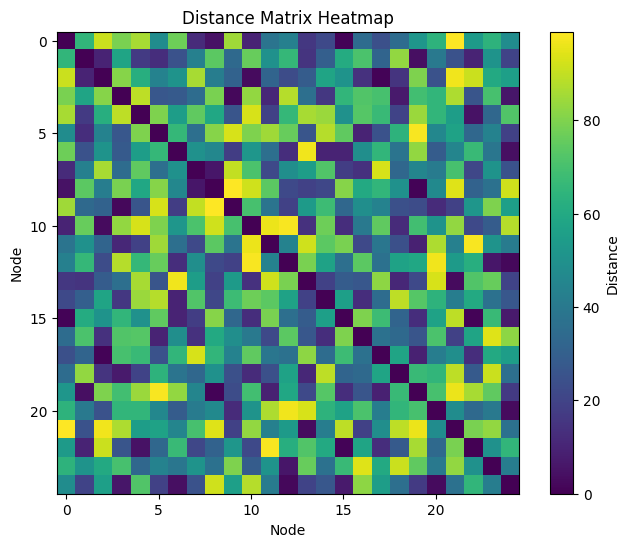

Constraints in the model:
----------------------------------------
Capacity constraint: ensures demand per route does not exceed vehicle capacity.
Time window constraint: ensures arrival times are within node time windows.
Resource constraint: ensures resource consumption per route within limits.
----------------------------------------
Number of vehicles: 5
Vehicle capacity: 30
Resource limits per vehicle: [100, 100, 100, 100, 100]
Time windows per node:
  Node 0: 38 - 57
  Node 1: 16 - 64
  Node 2: 32 - 78
  Node 3: 48 - 79
  Node 4: 15 - 45
  Node 5: 35 - 64
  Node 6: 6 - 24
  Node 7: 24 - 42
  Node 8: 33 - 67
  Node 9: 19 - 43
  Node 10: 37 - 87
  Node 11: 10 - 60
  Node 12: 33 - 77
  Node 13: 25 - 43
  Node 14: 31 - 67
  Node 15: 28 - 67
  Node 16: 49 - 77
  Node 17: 8 - 38
  Node 18: 21 - 43
  Node 19: 25 - 54
  Node 20: 3 - 53
  Node 21: 48 - 63
  Node 22: 40 - 84
  Node 23: 45 - 71
  Node 24: 46 - 78

No solution found!


In [ ]:
import csv
import random
import matplotlib.pyplot as plt
import networkx as nx
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# Function to generate a sample symmetric distance matrix and save to CSV
def generate_sample_csv(file_path, num_nodes=25):
    """
    Generates a symmetric distance matrix with random distances
    and saves it as a CSV file.
    """
    matrix = []
    for i in range(num_nodes):
        row = []
        for j in range(num_nodes):
            if i == j:
                row.append(0)  # Distance to self is zero
            elif j < i:
                # Symmetric value from earlier row
                row.append(matrix[j][i])
            else:
                dist = random.randint(1, 100)
                row.append(dist)
        matrix.append(row)

    # Save to CSV
    with open(file_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        for row in matrix:
            writer.writerow(row)

# Function to load the distance matrix from CSV
def load_distance_matrix_from_csv(file_path):
    """
    Loads a distance matrix from a CSV file.
    Returns a list of lists (matrix).
    """
    distance_matrix = []
    with open(file_path, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            # Convert string values to integers
            distance_row = list(map(int, row))
            distance_matrix.append(distance_row)
    return distance_matrix

# Function to create the data model for the VRP
def create_data_model(distance_matrix):
    """
    Creates and returns the data dictionary for VRP, including demands,
    time windows, resources, capacities, etc.
    """
    data = {}
    num_nodes = len(distance_matrix)
    num_vehicles = 5
    depot = 0

    # Generate random demands between 1 and 10 for each node
    demands = [0] + [random.randint(1, 10) for _ in range(1, num_nodes)]

    # Generate random time windows for each node
    time_windows = []
    for _ in range(num_nodes):
        start = random.randint(0, 50)
        end = start + random.randint(10, 50)
        time_windows.append((start, end))

    # Set vehicle capacity
    vehicle_capacity = 30

    # Assign resources to vehicles and nodes
    vehicle_resources = [100 for _ in range(num_vehicles)]
    resource_consumption = [0] + [random.randint(1, 10) for _ in range(1, num_nodes)]

    # Store all data in dictionary
    data['distance_matrix'] = distance_matrix
    data['demands'] = demands
    data['time_windows'] = time_windows
    data['num_vehicles'] = num_vehicles
    data['depot'] = depot
    data['vehicle_capacity'] = vehicle_capacity
    data['vehicle_resources'] = vehicle_resources
    data['resource_consumption'] = resource_consumption
    return data

# Function to visualize distance matrix as heatmap
def visualize_distance_matrix(distance_matrix):
    """
    Displays the distance matrix as a heatmap for visual inspection.
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='viridis')
    plt.colorbar(label='Distance')
    plt.title('Distance Matrix Heatmap')
    plt.xlabel('Node')
    plt.ylabel('Node')
    plt.show()

# Function to print all constraints in the model
def print_constraints(routing, data):
    """
    Prints all the constraints added to the routing model.
    """
    print("Constraints in the model:")
    print("-" * 40)
    print("Capacity constraint: ensures demand per route does not exceed vehicle capacity.")
    print("Time window constraint: ensures arrival times are within node time windows.")
    print("Resource constraint: ensures resource consumption per route within limits.")
    print("-" * 40)
    print(f"Number of vehicles: {data['num_vehicles']}")
    print(f"Vehicle capacity: {data['vehicle_capacity']}")
    print(f"Resource limits per vehicle: {data['vehicle_resources']}")
    print("Time windows per node:")
    for idx, (start, end) in enumerate(data['time_windows']):
        print(f"  Node {idx}: {start} - {end}")
    print()

# Function to visualize routes with flows on a graph
def visualize_solution(data, manager, routing, solution):
    """
    Visualizes the routes of all vehicles on a directed graph.
    """
    plt.figure(figsize=(10, 8))
    colors = plt.cm.get_cmap('tab20', data['num_vehicles'])

    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_nodes = []
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_nodes.append(node_index)
            previous_index = index
            index = solution.Value(routing.NextVar(index))
        # Add last node
        route_nodes.append(manager.IndexToNode(index))
        # Plot arrows for route flow
        for i in range(len(route_nodes) - 1):
            from_node = route_nodes[i]
            to_node = route_nodes[i + 1]
            plt.arrow(
                from_node, to_node,
                dx=to_node - from_node,
                dy=to_node - from_node,
                head_width=0.2,
                length_includes_head=True,
                color=colors(vehicle_id)
            )
        # Mark depot with a circle
        plt.plot(route_nodes[0], route_nodes[-1], 'o', color=colors(vehicle_id), label=f'Vehicle {vehicle_id}')
    plt.title('Routes Visualization with Flows')
    plt.xlabel('Node Index')
    plt.ylabel('Node Index')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main function to set up and solve the VRP
def main():
    # Load distance matrix from CSV
    distance_matrix = load_distance_matrix_from_csv('distance_matrix-25.csv')
    # Create data model
    data = create_data_model(distance_matrix)

    # Visualize the distance matrix heatmap
    visualize_distance_matrix(distance_matrix)

    # Create the routing index manager
    manager = pywrapcp.RoutingIndexManager(
        len(data['distance_matrix']),
        data['num_vehicles'],
        data['depot']
    )

    # Create Routing Model
    routing = pywrapcp.RoutingModel(manager)

    # Register distance callback
    def distance_callback(from_index, to_index):
        """
        Returns the distance between the two nodes.
        """
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add capacity constraint dimension
    def demand_callback(from_index):
        """
        Returns the demand of the node.
        """
        # from_index is an internal solver index, convert it to a node index
        node_index = manager.IndexToNode(from_index)
        return data['demands'][node_index]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        [data['vehicle_capacity']] * data['num_vehicles'],  # vehicle capacities
        True,  # start cumul to zero
        'Capacity'
    )

    # Add time window constraint dimension
    def time_callback(from_index, to_index):
        """
        Returns travel time between nodes (here, same as distance).
        """
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    time_callback_index = routing.RegisterTransitCallback(time_callback)
    horizon = 200  # maximum route duration
    routing.AddDimension(
        time_callback_index,
        30,  # allow waiting time
        horizon,
        False,  # do not force start cumul to zero
        'Time'
    )

    time_dimension = routing.GetDimensionOrDie('Time')
    # Set time window bounds for each node
    for node_idx, (start, end) in enumerate(data['time_windows']):
        index = manager.NodeToIndex(node_idx)
        time_dimension.CumulVar(index).SetRange(start, end)
    # Set start time bounds for each vehicle
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        time_dimension.CumulVar(index).SetRange(0, horizon)

    # Add resource constraint dimension
    def resource_callback(from_index):
        """
        Returns resource consumption at node.
        """
        # from_index is an internal solver index, convert it to a node index
        node_index = manager.IndexToNode(from_index)
        return data['resource_consumption'][node_index]

    resource_callback_index = routing.RegisterUnaryTransitCallback(resource_callback)
    routing.AddDimensionWithVehicleCapacity(
        resource_callback_index,
        0,
        data['vehicle_resources'],
        True,
        'Resource'
    )

    # Set search parameters
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.time_limit.FromSeconds(30)

    # Print all constraints
    print_constraints(routing, data)

    # Solve the problem
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print('Solution found. Visualizing routes...')
        visualize_solution(data, manager, routing, solution)
    else:
        print('No solution found!')

# Run the main function
if __name__ == '__main__':
    main()